In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## Thresholding Segmentation 

#### Simple / Global Thresholding

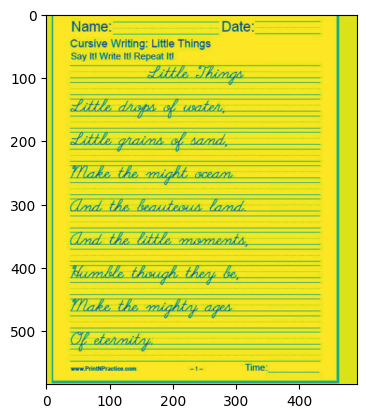

In [6]:
image_gray = cv2.imread("./assets/handwriting.png", 0)
plt.imshow(image_gray)

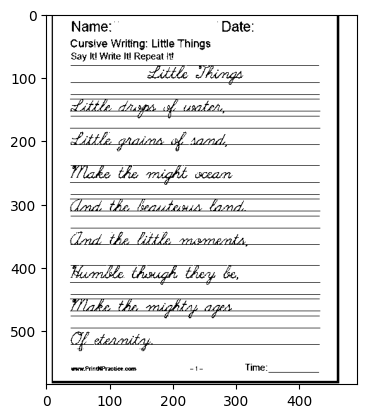

In [14]:
retval, binary = cv2.threshold(image_gray, 170, 255, cv2.THRESH_BINARY)

plt.imshow(binary, cmap="grey")

#### Adaptive thresholding

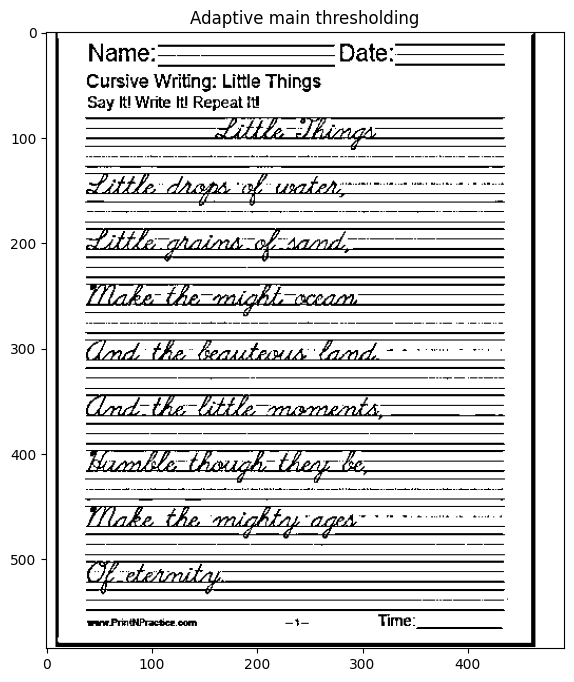

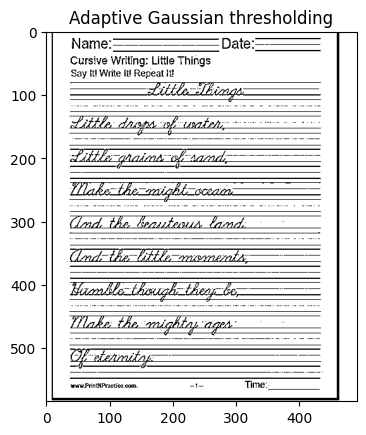

In [22]:
adaptive_main = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 15)
adaptive_gaussian = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 15)

plt.figure(figsize=(10, 8))

plt.imshow(adaptive_main, cmap="gray")
plt.title("Adaptive main thresholding")
plt.show()

plt.imshow(adaptive_gaussian, cmap="gray")
plt.title("Adaptive Gaussian thresholding")
plt.show()

## K-Means Clustering

In [ ]:
image = cv2.imread("./assets/shape2.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# make 2D array, basically image has 3 channel (height, width, 3) 3 = mean RGB
pixel_values = image.reshape((-1, 3)) # there are 1 row and three RGB channel, each pixel rgb value
pixel_values = np.float32(pixel_values) # kmeans want to float type data for good calculation
pixel_values

array([[247., 247., 247.],
       [247., 247., 247.],
       [247., 247., 247.],
       ...,
       [247., 247., 247.],
       [247., 247., 247.],
       [247., 247., 247.]], shape=(308967, 3), dtype=float32)

In [ ]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3
""" 
🔸 K-means একটি iterative অ্যালগরিদম — এখানে নির্ধারণ করতে হয় কবে এটি থামবে।
criteria মানে: কখন loop থামবে।
cv2.TERM_CRITERIA_EPS → যদি centroid এর পরিবর্তন 0.2 এর নিচে চলে আসে।
cv2.TERM_CRITERIA_MAX_ITER → অথবা যদি 100 বার iteration হয়ে যায়।
তাই এই দুইটার কোনো একটায় পৌঁছালে loop থেমে যাবে।
🔸 k = 3 → আমরা চাই ছবিটিকে 3টি cluster (segment) এ ভাগ করতে।

"""

_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

""""
Parameters ব্যাখ্যা:

pixel_values → ইনপুট ডেটা (R, G, B)
None → কোনো প্রাথমিক লেবেল নেই
criteria → থেমে যাওয়ার শর্ত
10 → 10 বার আলাদা ভাবে run করে best টি বেছে নিবে
cv2.KMEANS_RANDOM_CENTERS → initial centroid র‍্যান্ডমভাবে বেছে নেয়া হবে
Return:
_ → compactness (আপাতত দরকার নেই)

labels → প্রতিটি পিক্সেল কোন ক্লাস্টারে পড়েছে, তার index (shape: [num_pixels, 1])

centers → প্রতিটি ক্লাস্টারের RGB মান (shape: [k, 3])
"""

In [33]:
print(labels.shape)
print(centers)

(308967, 1)
[[247.77768  241.73474  242.13791 ]
 [  3.532639 151.38976  167.53056 ]
 [254.48509  120.00362   24.990463]]


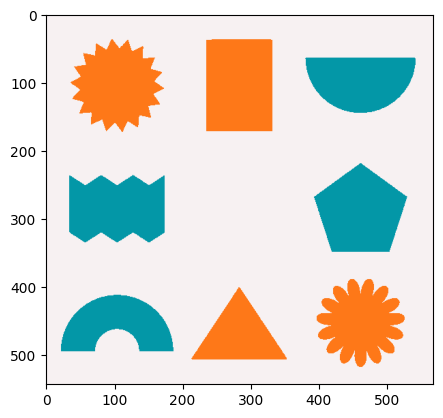

In [ ]:
# convert center into integer
centers = np.uint8(centers)
# find color from centers using labels
segmented_image = centers[labels.flatten()]

# back again image format (height, width, 3)
segmented_image = segmented_image.reshape(image.shape)

# show image
plt.imshow(segmented_image)

### Watershed algorighm

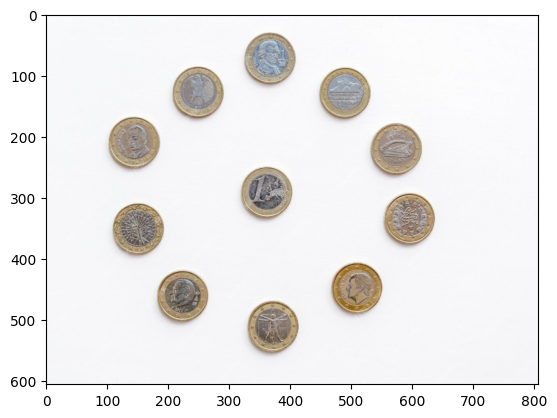

In [96]:
# step 1: load image and convert to grayscale
image = cv2.imread("./assets/coins.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_image = image.copy()
plt.imshow(original_image)

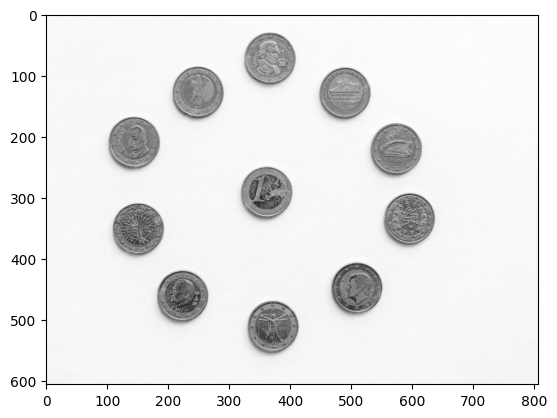

In [97]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap="gray")

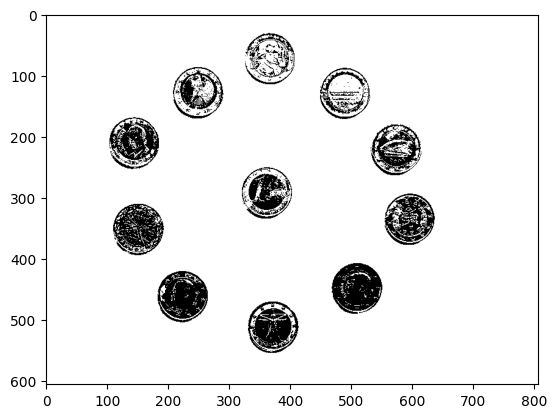

In [100]:
# Step 2: Thresholding
_, thresh = cv2.threshold(gray_image, 150, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap="gray")

In [102]:
# Step 3: Noise removal
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=4)

# Step 4: Sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=2)

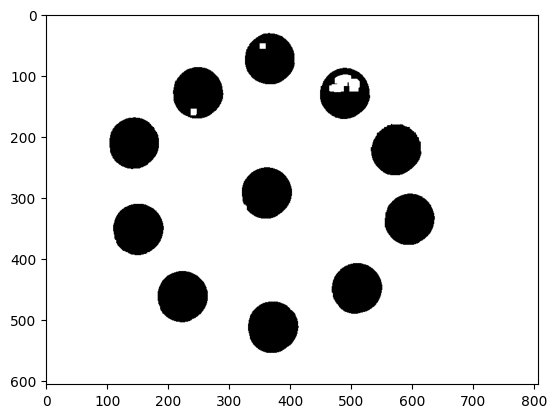

In [103]:
plt.imshow(opening, cmap="gray")

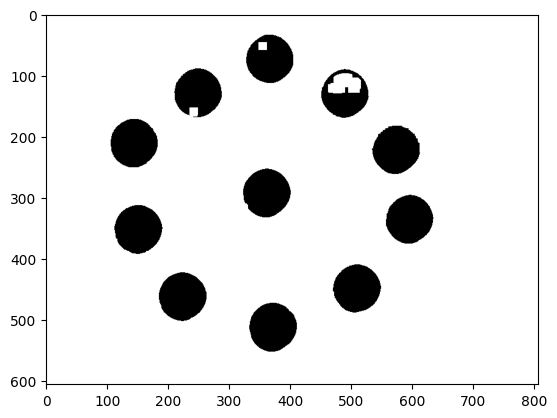

In [104]:
plt.imshow(sure_bg, cmap="gray")

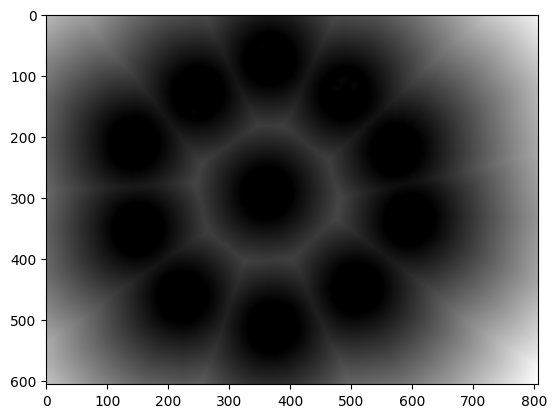

In [105]:
# Sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.3 * dist_transform.max(), 255, 0)

plt.imshow(dist_transform, cmap="gray")

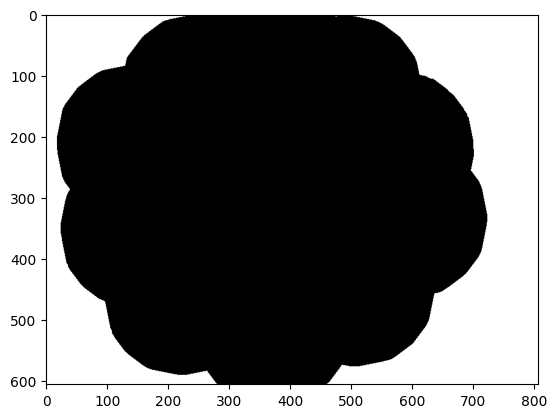

In [106]:

sure_fg = np.uint8(sure_fg)
plt.imshow(sure_fg, cmap="gray")

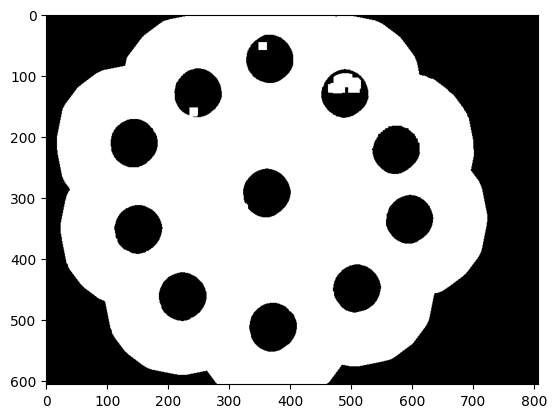

In [107]:
# Step 6: Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)
plt.imshow(unknown, cmap="gray")

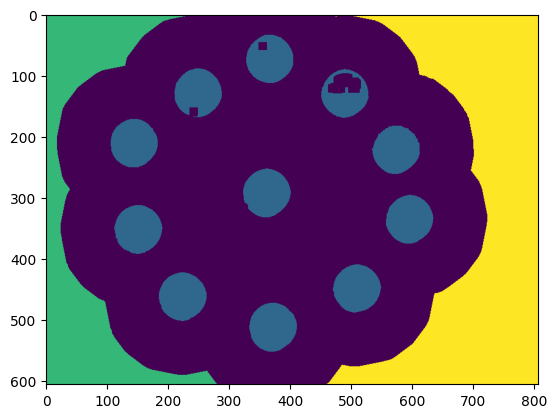

In [108]:
# Step 7: Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels so that background is not 0
markers = markers + 1

# Mark the region of unknown with zero
markers[unknown == 255] = 0
plt.imshow(markers) 

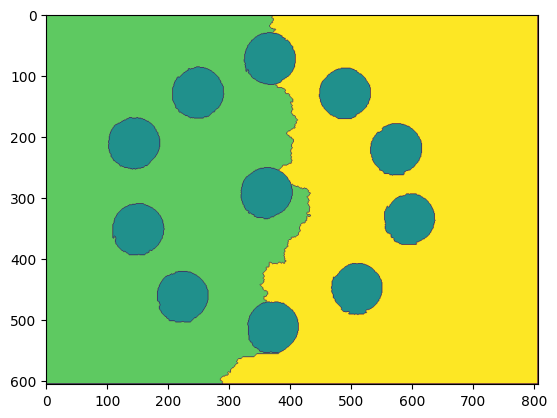

In [109]:
# Step 8: Apply watershed
markers = cv2.watershed(image, markers) 
plt.imshow(markers)

In [114]:
# gray image shape
coin_mask = np.zeros_like(gray_image)

unique_labels = np.unique(markers)

instance_number = 1
font = cv2.FONT_HERSHEY_COMPLEX

for label in unique_labels:
    if label == 0 or label == -1:
        continue
    
    mask = np.uint8(markers == label)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        area = cv2.contourArea(contour)
        parameter = cv2.arcLength(contour, True)

        if parameter == 0:
            continue
        
        circularity = 4 * np.pi * (area / (parameter * parameter))
        if 0.7 < circularity < 1.2 and area > 1000:
            cv2.drawContours(original_image, [contour], -1, (0, 255, 0), 2)
            x,y,w,h = cv2.boundingRect(contour)
            cv2.putText(original_image, f"coin {instance_number}", (x, y-10), font, 0.6, (255, 0, 0), 2)
            coin_mask = cv2.bitwise_or(coin_mask, mask)
            cv2.rectangle(original_image, (x-5, y-5), (x+w+5, y+h+5), (160, 150, 250), 2)
            instance_number += 1

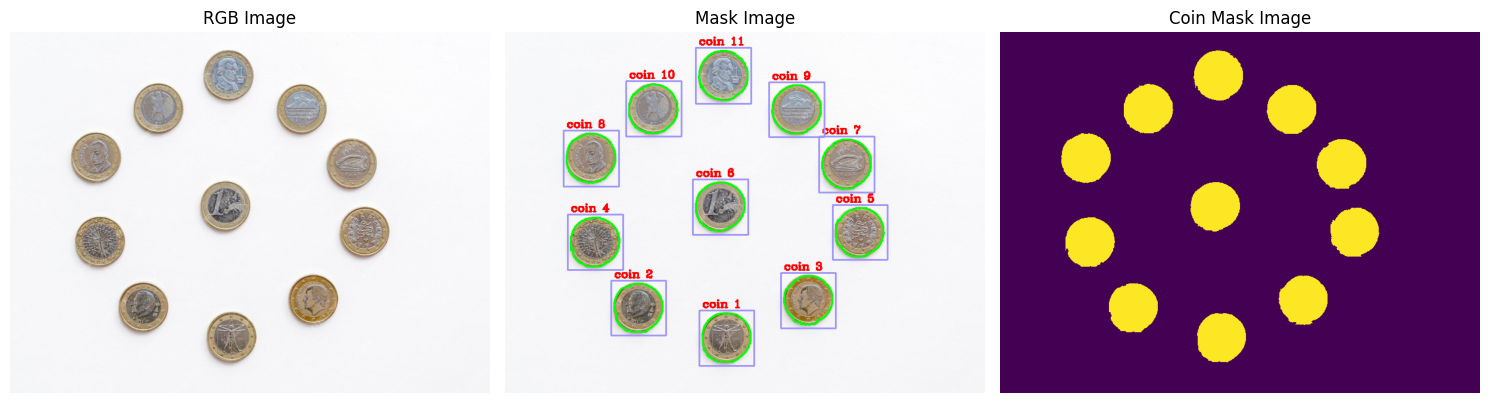

In [115]:
# Plotting
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(original_image)
plt.title("Mask Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(coin_mask)
plt.title("Coin Mask Image")
plt.axis("off")

plt.tight_layout()
plt.show()